## Previsão de preços de carros

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [91]:
df = pd.read_excel('carprice.xlsx')

In [92]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [93]:
# verificando o tamanho da dataset

df.shape

(197, 26)

In [94]:
# verificando o formato dos dados

df.dtypes

symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

In [95]:
# transformando variáveis categóricas em numéricas - somente as importantes
# fuel-type, body-style, engine-type

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['fuel-type'] = le.fit_transform(df['fuel-type'])
df['engine-type'] = le.fit_transform(df['engine-type'])
df['body-style'] = le.fit_transform(df['body-style'])
df['make'] = le.fit_transform(df['make'])
df['num-of-doors'] = le.fit_transform(df['num-of-doors'])

In [96]:
# arrumando os formatos para int 64

from numpy import int64

df['fuel-type'] = df['fuel-type'].astype(int64)
df['engine-type'] = df['engine-type'].astype(int64)
df['body-style'] = df['body-style'].astype(int64)
df['make'] = df['make'].astype(int64)
df['num-of-doors'] = df['num-of-doors'].astype(int64)

In [97]:
df.dtypes

symboling              int64
normalized-losses    float64
make                   int64
fuel-type              int64
aspiration            object
num-of-doors           int64
body-style             int64
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type            int64
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

In [98]:
# Removendo missing values da variável alvo
# neste caso vou remover ?

df['price'].head(11)

0     13495
1     16500
2     16500
3     13950
4     17450
5     15250
6     17710
7     18920
8     23875
9         ?
10    16430
Name: price, dtype: object

In [99]:
# Verificando linhas com a string '?'

df[df['price']=='?']

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
9,0,NaN,1,1,turbo,1,2,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?
43,1,NaN,6,1,std,1,3,fwd,front,94.5,...,90,2bbl,3.03,3.11,9.6,70,5400,38,43,?
44,0,NaN,6,1,std,0,3,fwd,front,94.5,...,90,2bbl,3.03,3.11,9.6,70,5400,38,43,?
123,1,NaN,15,1,std,1,2,rwd,front,98.4,...,203,mpfi,3.94,3.11,10.0,288,5750,17,28,?


In [100]:
# excluindo valores desconhecidos da variável alvo, neste caso é o ?

df.drop(index=[9,43,44,123], inplace = True)

In [101]:
# verificando se existem outros missing values

def is_missing(df):
    for col in df.columns:
        if df[col].isnull().values.any():
            print('Missing Values em: {0}'.format(str(col)))
        else:
            print('{0} : não pussui missing values'.format(str(col)))
            
is_missing(df)

symboling : não pussui missing values
Missing Values em: normalized-losses
make : não pussui missing values
fuel-type : não pussui missing values
aspiration : não pussui missing values
num-of-doors : não pussui missing values
body-style : não pussui missing values
drive-wheels : não pussui missing values
engine-location : não pussui missing values
wheel-base : não pussui missing values
length : não pussui missing values
width : não pussui missing values
height : não pussui missing values
curb-weight : não pussui missing values
engine-type : não pussui missing values
num-of-cylinders : não pussui missing values
engine-size : não pussui missing values
fuel-system : não pussui missing values
bore : não pussui missing values
stroke : não pussui missing values
compression-ratio : não pussui missing values
horsepower : não pussui missing values
peak-rpm : não pussui missing values
city-mpg : não pussui missing values
highway-mpg : não pussui missing values
price : não pussui missing values


In [102]:
# apenas normalized-losses possui missing values

df['normalized-losses'].head(30)

0       NaN
1       NaN
2       NaN
3     164.0
4     164.0
5       NaN
6     158.0
7       NaN
8     158.0
10    192.0
11    192.0
12    188.0
13    188.0
14      NaN
15      NaN
16      NaN
17      NaN
18    121.0
19     98.0
20     81.0
21    118.0
22    118.0
23    118.0
24    148.0
25    148.0
26    148.0
27    110.0
28    145.0
29    137.0
30    137.0
Name: normalized-losses, dtype: float64

In [103]:
# tratando missing values

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')

df['normalized-losses'] = imputer.fit_transform(df[['normalized-losses']])

In [104]:
df.dtypes

symboling              int64
normalized-losses    float64
make                   int64
fuel-type              int64
aspiration            object
num-of-doors           int64
body-style             int64
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type            int64
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

In [105]:
# convertendo a variável target para numérico float

df['price'] = df['price'].astype(int64)

In [106]:
df.dtypes

symboling              int64
normalized-losses    float64
make                   int64
fuel-type              int64
aspiration            object
num-of-doors           int64
body-style             int64
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type            int64
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

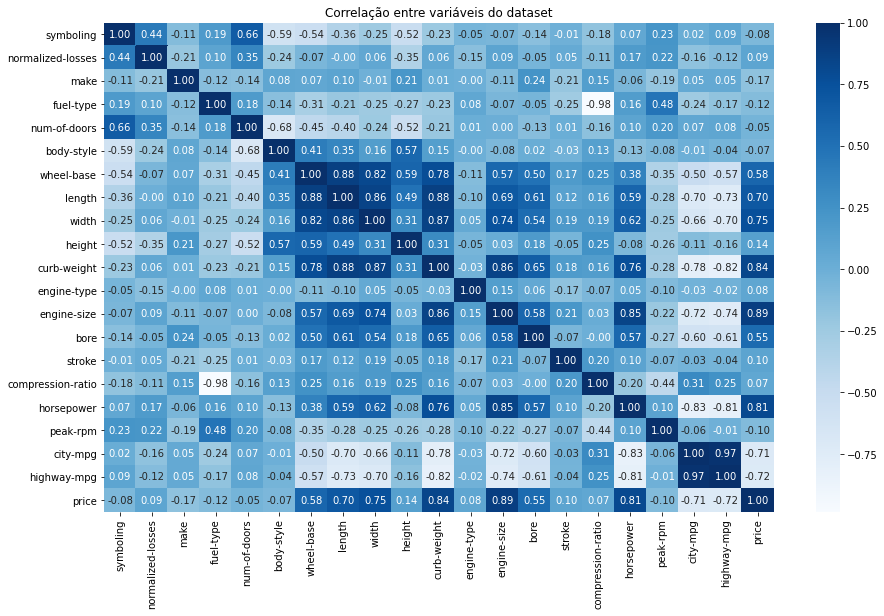

In [107]:
# verificando se exite correlação entre as variáveis

import matplotlib.pyplot as plt
import seaborn as sns

def plot_corr(df):
    plt.figure(figsize=(15, 9))
    sns.heatmap(df.corr(),
            annot = True,
            fmt = '.2f',
            cmap='Blues')
    plt.title('Correlação entre variáveis do dataset')
    plt.show()

    
plot_corr(df)

## As cores mais claras representam uma maior correlação negativa
## As cores mais escuras representam correlação positiva

### highway-mpg, city-mpg, horsepower, engine-size, curb-weight, width e length possuem melhor correlação com price

# Construção do modelo

In [108]:
# definindo os dados de input e output
# É necessário remover variáveis do tipo string

X = df.drop(['aspiration', 'drive-wheels', 'engine-location', 'num-of-cylinders', 'fuel-system'], axis=1).values

y = df['price'].values

In [109]:
# selecionando as melhores variáveis para o modelo utilizando SelectKBest

from sklearn.feature_selection import SelectKBest

# vamos utilizar o método f_regression pois o problema é de regressão
# número de variáveis = 9

from sklearn.feature_selection import f_regression
selector = SelectKBest(score_func=f_regression, k=9)

In [110]:
fit = selector.fit(X, y)

In [111]:
X = fit.transform(X)

In [112]:
X

array([[ 88.6, 168.8,  64.1, ..., 111. ,  21. ,  27. ],
       [ 88.6, 168.8,  64.1, ..., 111. ,  21. ,  27. ],
       [ 94.5, 171.2,  65.5, ..., 154. ,  19. ,  26. ],
       ...,
       [109.1, 188.8,  68.9, ..., 134. ,  18. ,  23. ],
       [109.1, 188.8,  68.9, ..., 106. ,  26. ,  27. ],
       [109.1, 188.8,  68.9, ..., 114. ,  19. ,  25. ]])

In [113]:
# Normalizando os dados

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scale = scaler.fit(X)
X = scale.transform(X)

In [114]:
# dividindo os dados em treino e teste

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [117]:
# treinando e salvando o modelo..

#importando o modelo e métricas

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr = LinearRegression()

In [118]:
lr.fit(X_train, y_train)

LinearRegression()

In [119]:
Y_pred = lr.predict(X_test)

In [123]:
# verificando a precisão do modelo
score = r2_score(y_test, Y_pred)

print('Acurácia de : {0:.2f}%'.format(score*100))

Acurácia de : 81.50%


In [125]:
# salvando o modelo

import joblib

joblib.dump(lr, 'linear_reg_modelo.pkl')

['linear_reg_modelo.pkl']